# CNN-XGBoost Pneumonia Classification + XAI
**Paper:** *An improvement of the CNN-XGboost model for pneumonia disease classification*  
**XAI Methods:** SHAP · LIME · GradCAM · Guided GradCAM

## Cell 1 — Install Dependencies

In [1]:
!pip install -q xgboost shap lime grad-cam albumentations kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.6 MB/s eta 0:00:0000:0100:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Cell 2 — Imports

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from pytorch_grad_cam import GradCAM, GuidedBackpropReLUModel
# We'll use Keras-compatible GradCAM manually (no PyTorch needed)

import kagglehub
warnings.filterwarnings('ignore')
print('All imports OK')

2026-05-11 15:02:32.948061: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778511753.163723      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778511753.224516      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778511753.704949      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778511753.704994      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778511753.704997      57 computation_placer.cc:177] computation placer alr

All imports OK


## Cell 3 — ⚙️ Hyperparameters (Edit Here)

In [3]:
# ── Dataset ──────────────────────────────────────────────
IMG_SIZE      = 64          # resize to 64×64 (paper setting)
N_NORMAL      = 6000        # normal samples
N_PNEUMONIA   = 6000        # pneumonia samples
RANDOM_SEED   = 42

# ── CNN Training ─────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 40
LEARNING_RATE = 0.0001
DROPOUT       = 0.7
L2_REG        = 0.0001
VAL_SPLIT     = 0.2         # 20% of train → validation

# ── XGBoost ──────────────────────────────────────────────
XGB_LR        = 0.001
XGB_N_EST     = 200

# ── XAI ──────────────────────────────────────────────────
N_XAI_SAMPLES = 5           # number of test images to explain

# ── Classes ──────────────────────────────────────────────
CLASSES       = ['Normal', 'Pneumonia']
N_CLASSES     = 2

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Hyperparameters set.')

Hyperparameters set.


## Cell 4 — Load Data

In [4]:
_hub_path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')

def _find_data_dir(root):
    for dirpath, _, filenames in os.walk(root):
        if 'stage_2_train_labels.csv' in filenames:
            return dirpath
    return None

DATA_DIR = _find_data_dir(_hub_path) or '/kaggle/input/rsna-pneumonia-detection-challenge'
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, 'stage_2_train_images')

labels_df     = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_train_labels.csv'))
class_info_df = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_detailed_class_info.csv'))

# One row per patient → binary label (Target: 0=Normal, 1=Pneumonia)
patient_labels = labels_df.groupby('patientId')['Target'].max().reset_index()
print(f"Total patients : {len(patient_labels)}")
print(patient_labels['Target'].value_counts())

Total patients : 26684
Target
0    20672
1     6012
Name: count, dtype: int64


## Cell 5 — Sample 12,000 Images (6k Normal + 6k Pneumonia)

In [5]:
normal_ids    = patient_labels[patient_labels['Target']==0]['patientId'].tolist()
pneumonia_ids = patient_labels[patient_labels['Target']==1]['patientId'].tolist()

random.shuffle(normal_ids)
random.shuffle(pneumonia_ids)

selected_normal    = normal_ids[:N_NORMAL]
selected_pneumonia = pneumonia_ids[:N_PNEUMONIA]

selected_ids    = selected_normal + selected_pneumonia
selected_labels = [0]*N_NORMAL + [1]*N_PNEUMONIA

print(f"Selected → Normal: {N_NORMAL} | Pneumonia: {N_PNEUMONIA} | Total: {len(selected_ids)}")

Selected → Normal: 6000 | Pneumonia: 6000 | Total: 12000


## Cell 6 — Preprocessing & Augmentation

In [8]:
# ============================================================
# CELL — Load Dataset with Augmentation (Optimized + Debugging)
# ============================================================

from tqdm import tqdm
import albumentations as A
import numpy as np
import os
import cv2
import pydicom

# Augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.GaussNoise(p=0.3),
])

def load_dicom(patient_id):
    """
    Load DICOM image → RGB numpy array (64×64)
    """
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")

    dcm = pydicom.dcmread(path)

    img = dcm.pixel_array.astype(np.uint8)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Convert Gray → RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img


def load_dataset(ids, labels, augment_fn=None):
    X, y = [], []

    for pid, lbl in tqdm(zip(ids, labels), total=len(ids)):

        try:
            # Load image
            img = load_dicom(pid)

            # Apply augmentation only for pneumonia class
            if augment_fn is not None and lbl == 1:
                img = augment_fn(image=img)["image"]

            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0

            X.append(img)
            y.append(lbl)

        except Exception as e:
            print(f"Error loading {pid}: {e}")

    return np.array(X), np.array(y)


print("Loading images (this may take a few minutes)...")

X_all, y_all = load_dataset(
    selected_ids,
    selected_labels,
    augment_fn=augment
)

print(f"\nDataset shape: {X_all.shape}")
print(f"Labels distribution: {np.bincount(y_all)}")

Loading images (this may take a few minutes)...


100%|██████████| 12000/12000 [03:00<00:00, 66.45it/s]



Dataset shape: (12000, 64, 64, 3)
Labels distribution: [6000 6000]


## Cell 7 — Train / Validation / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_SEED, stratify=y_all)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SPLIT, random_state=RANDOM_SEED, stratify=y_train)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 8160
Val   : 2040
Test  : 1800


## Cell 8 — CNN Architecture (Paper Figure 4)

In [11]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), n_classes=N_CLASSES):
    inp = layers.Input(shape=input_shape)

    # Block 1 — two Conv2D (paper uses Conv2D for block 1)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # Blocks 2-5 — SeparableConv2D pairs + BN
    for filters in [32, 64, 128, 256]:
        x = layers.SeparableConv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.SeparableConv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.BatchNormalization()(x)

    # Flatten + Dense + Dropout (paper: 128 neurons, L2, dropout 0.7)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)

    # Output
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

I0000 00:00:1778512916.578977      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 32)     │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 16, 16, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 8, 8, 128)      │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 8, 8, 128)      │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_6              │ (None, 4, 4, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_7              │ (None, 4, 4, 256)      │        68,096 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 274,146 (1.05 MB)

 Trainable params: 273,186 (1.04 MB)

 Non-trainable params: 960 (3.75 KB)

## Cell 9 — Train CNN

Epoch 1/40


I0000 00:00:1778512934.253677     149 service.cc:152] XLA service 0x7f77b80499e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778512934.253736     149 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778512935.273866     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778512944.799976     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 320ms/step - accuracy: 0.6322 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.7132
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7005 - loss: 0.5388 - val_accuracy: 0.5000 - val_loss: 0.7130
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7901 - loss: 0.4597 - val_accuracy: 0.5000 - val_loss: 0.7169
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8286 - loss: 0.4076 - val_accuracy: 0.5000 - val_loss: 0.7311
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8512 - loss: 0.3724 - val_accuracy: 0.5000 - val_loss: 0.7575
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8577 - loss: 0.3568 - val_accuracy: 0.5000 - val_loss: 0.7971
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8654 - loss: 0.3418 - val_accuracy: 0.5000 - val_loss: 0.8525


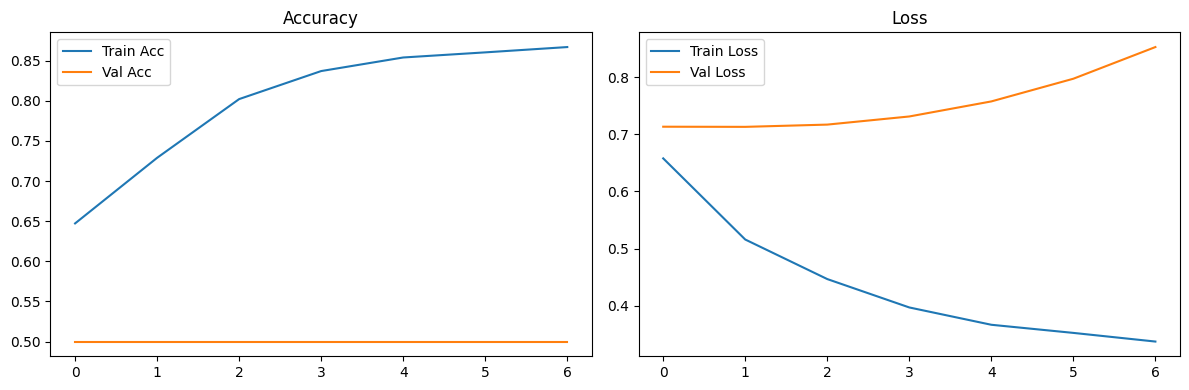

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('cnn_training_curves.png', dpi=150); plt.show()

## Cell 10 — Extract CNN Features for XGBoost

In [13]:
# Feature extractor = CNN without the output layer
feature_extractor = models.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output   # Dense(128) layer output
)

X_train_feat = feature_extractor.predict(X_train, batch_size=BATCH_SIZE, verbose=0)
X_val_feat   = feature_extractor.predict(X_val,   batch_size=BATCH_SIZE, verbose=0)
X_test_feat  = feature_extractor.predict(X_test,  batch_size=BATCH_SIZE, verbose=0)

print(f"Feature vector shape: {X_train_feat.shape}")

Feature vector shape: (8160, 128)


## Cell 11 — Train XGBoost Classifier

In [14]:
xgb_clf = xgb.XGBClassifier(
    learning_rate=XGB_LR,
    n_estimators=XGB_N_EST,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    tree_method='hist',       # fast training
    n_jobs=-1
)

xgb_clf.fit(
    X_train_feat, y_train,
    eval_set=[(X_val_feat, y_val)],
    verbose=False
)
print('XGBoost training done.')

XGBoost training done.


## Cell 12 — Evaluate CNN-XGBoost Model

=== CNN-XGBoost Classification Report ===
              precision    recall  f1-score   support

      Normal       0.79      0.82      0.81       900
   Pneumonia       0.81      0.78      0.80       900

    accuracy                           0.80      1800
   macro avg       0.80      0.80      0.80      1800
weighted avg       0.80      0.80      0.80      1800



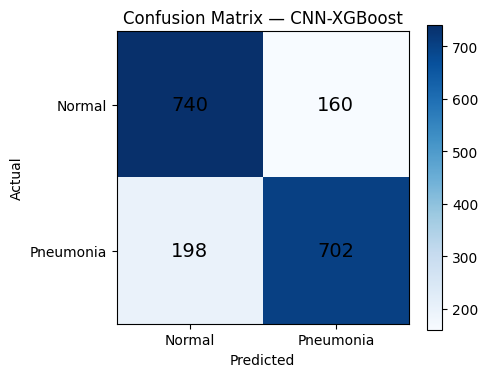

In [15]:
y_pred = xgb_clf.predict(X_test_feat)

print("=== CNN-XGBoost Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — CNN-XGBoost')
plt.colorbar(im); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150); plt.show()

---
# XAI Techniques
## Cell 13 — Helpers: Pick Test Samples

In [16]:
# Pick N_XAI_SAMPLES images (mix of both classes)
xai_indices = []
for cls in [0, 1]:
    cls_idx = np.where(y_test == cls)[0]
    xai_indices.extend(cls_idx[:N_XAI_SAMPLES].tolist())

X_xai = X_test[xai_indices]       # shape (N, 64, 64, 3)
y_xai = y_test[xai_indices]
print(f"XAI samples: {len(X_xai)} | labels: {y_xai}")

XAI samples: 10 | labels: [0 0 0 0 0 1 1 1 1 1]


## Cell 14 — XAI 1: SHAP (on XGBoost features)

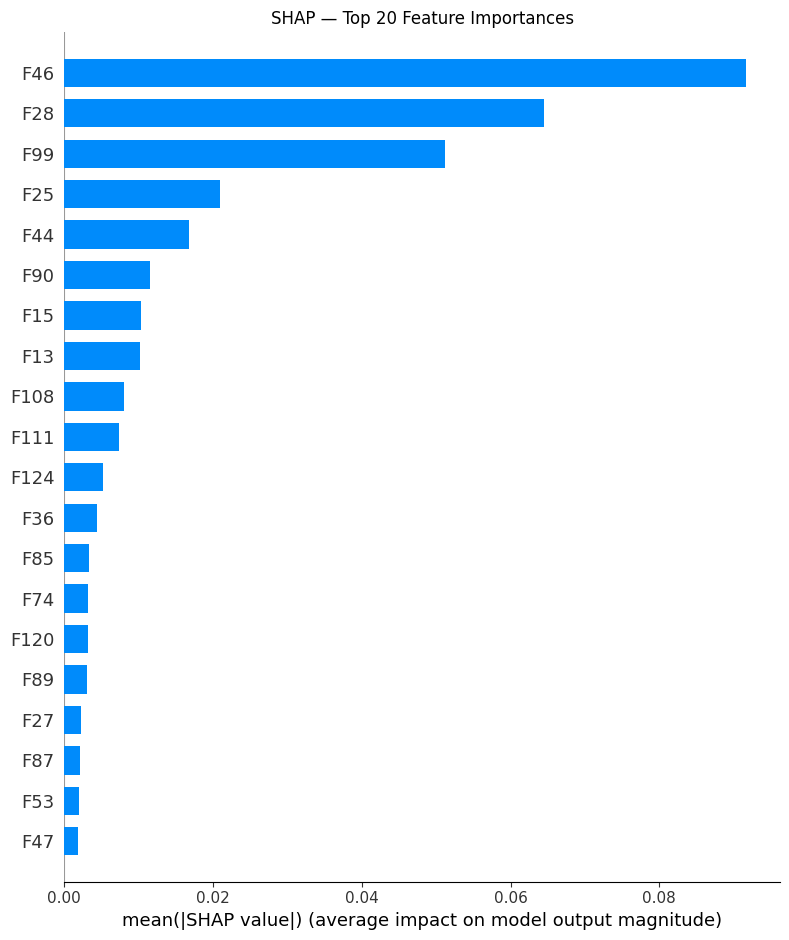

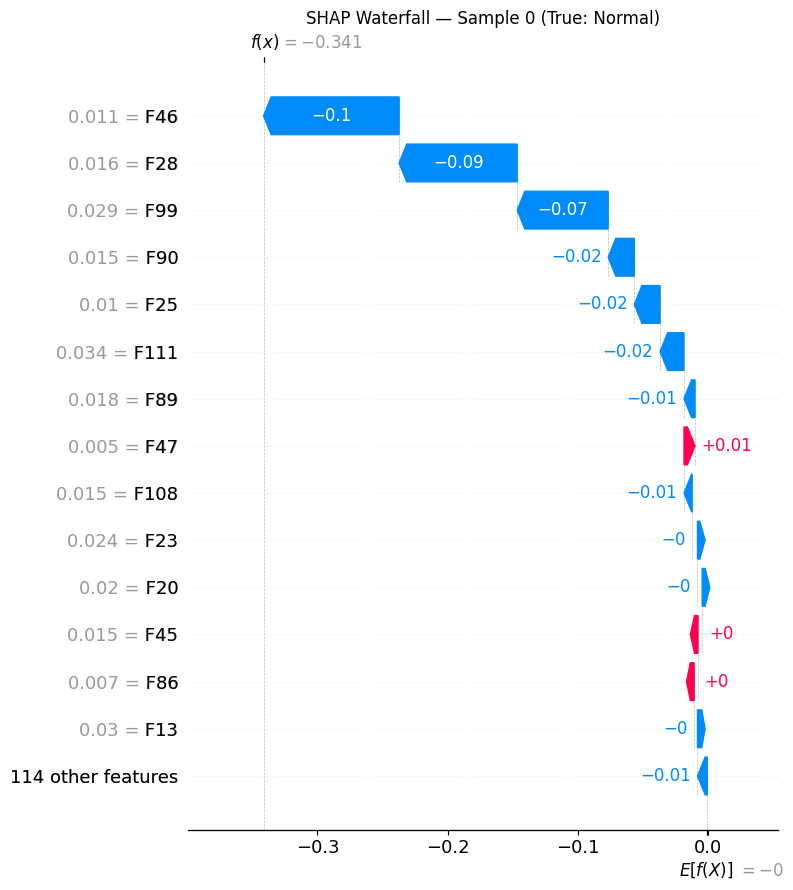

In [17]:
X_xai_feat = feature_extractor.predict(X_xai, verbose=0)

explainer_shap = shap.TreeExplainer(xgb_clf)
shap_values    = explainer_shap.shap_values(X_xai_feat)

# Summary bar plot — top 20 features
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values, X_xai_feat,
    feature_names=[f'F{i}' for i in range(X_xai_feat.shape[1])],
    plot_type='bar', max_display=20, show=False
)
plt.title('SHAP — Top 20 Feature Importances')
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150); plt.show()

# Waterfall for first sample
plt.figure(figsize=(10, 5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer_shap.expected_value,
        data=X_xai_feat[0],
        feature_names=[f'F{i}' for i in range(X_xai_feat.shape[1])]
    ),
    max_display=15, show=False
)
plt.title(f'SHAP Waterfall — Sample 0 (True: {CLASSES[y_xai[0]]})')
plt.tight_layout(); plt.savefig('shap_waterfall.png', dpi=150); plt.show()

## Cell 15 — XAI 2: LIME (on CNN predictions)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

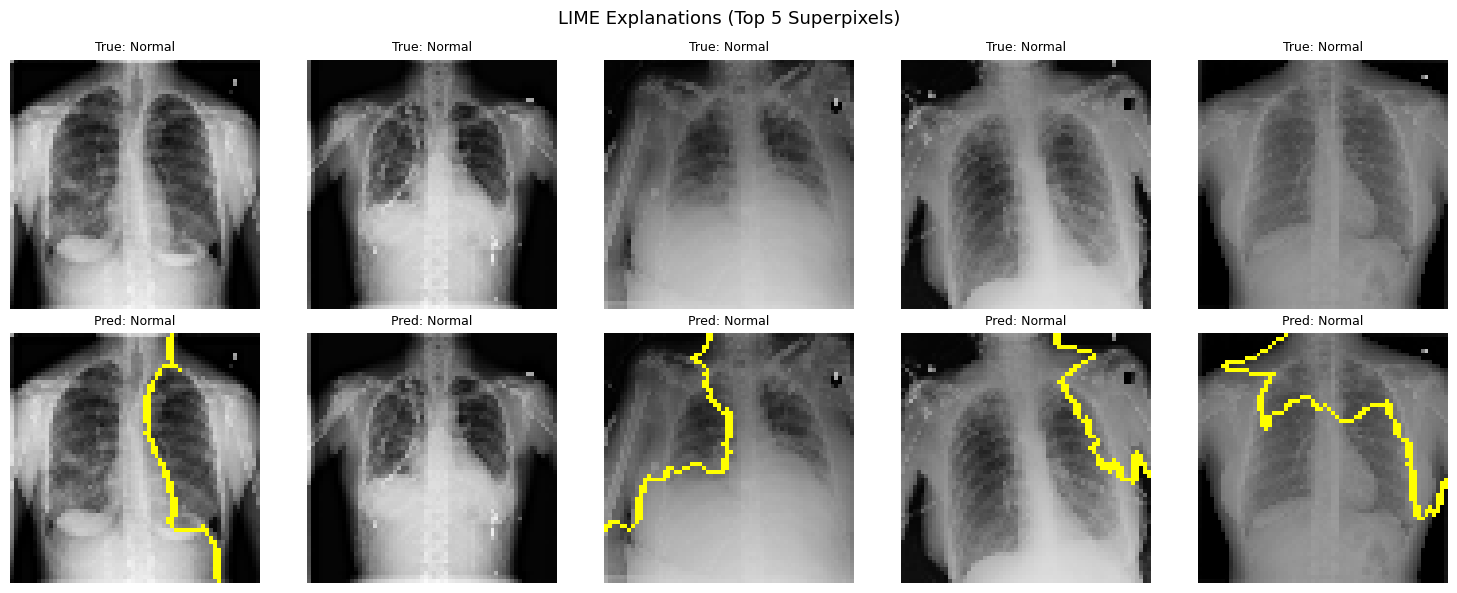

In [18]:
# Prediction function for LIME (uses CNN directly)
def cnn_predict_fn(images):
    imgs = images.astype(np.float32)
    if imgs.max() > 1.0:
        imgs /= 255.0
    return cnn_model.predict(imgs, verbose=0)

lime_explainer = lime_image.LimeImageExplainer(random_state=RANDOM_SEED)

fig, axes = plt.subplots(2, N_XAI_SAMPLES, figsize=(3*N_XAI_SAMPLES, 6))
for i in range(N_XAI_SAMPLES):
    img_uint8 = (X_xai[i] * 255).astype(np.uint8)
    explanation = lime_explainer.explain_instance(
        img_uint8, cnn_predict_fn,
        top_labels=1, hide_color=0, num_samples=500
    )
    pred_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_label, positive_only=True, num_features=5, hide_rest=False
    )
    axes[0, i].imshow(X_xai[i])
    axes[0, i].set_title(f'True: {CLASSES[y_xai[i]]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1, i].set_title(f'Pred: {CLASSES[pred_label]}', fontsize=9)
    axes[1, i].axis('off')

fig.suptitle('LIME Explanations (Top 5 Superpixels)', fontsize=13)
plt.tight_layout(); plt.savefig('lime_explanations.png', dpi=150); plt.show()

## Cell 16 — XAI 3 & 4: GradCAM + Guided GradCAM

In [19]:
# ── GradCAM helpers ─────────────────────────────────────────────────────────

def get_gradcam(model, img_array, last_conv_layer_name):
    """Compute GradCAM heatmap for a single image (1, H, W, C)."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        loss = predictions[:, pred_class]

    grads   = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_class)


def get_guided_gradcam(model, img_array, last_conv_layer_name):
    """Guided GradCAM = element-wise product of Guided Backprop × GradCAM."""
    # --- Guided Backprop (register custom gradient)
    @tf.custom_gradient
    def guided_relu(x):
        def grad(dy):
            return dy * tf.cast(dy > 0, dtype=tf.float32) * \
                        tf.cast(x > 0,  dtype=tf.float32)
        return tf.nn.relu(x), grad

    # Build guided model with patched ReLUs
    guided_model_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x_g = guided_model_input
    for layer in model.layers[1:]:
        cfg = layer.get_config()
        if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D,
                              layers.Dense)):
            x_g = layer(x_g)
            if cfg.get('activation') == 'relu':
                x_g = layers.Lambda(guided_relu)(x_g)
        else:
            x_g = layer(x_g)

    guided_model = tf.keras.Model(guided_model_input, x_g)
    guided_model.set_weights(model.get_weights())

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        preds = guided_model(img_array)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    guided_grads = tape.gradient(loss, img_array).numpy()[0]
    guided_grads = np.maximum(guided_grads, 0)              # keep positive
    guided_grads /= (guided_grads.max() + 1e-8)

    # GradCAM heatmap
    cam, pred = get_gradcam(model, img_array, last_conv_layer_name)
    cam_3ch   = np.stack([cam]*3, axis=-1)                  # broadcast to 3ch
    guided_cam = guided_grads * cam_3ch
    guided_cam /= (guided_cam.max() + 1e-8)
    return cam, guided_cam, pred


def overlay_heatmap(img, heatmap, alpha=0.5):
    heatmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * heatmap_color + (1 - alpha) * img, 0, 1)


# ── Find last conv layer name ────────────────────────────────────────────────
last_conv_name = None
for layer in reversed(cnn_model.layers):
    if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D)):
        last_conv_name = layer.name
        break
print(f"Last conv layer: {last_conv_name}")

Last conv layer: separable_conv2d_7


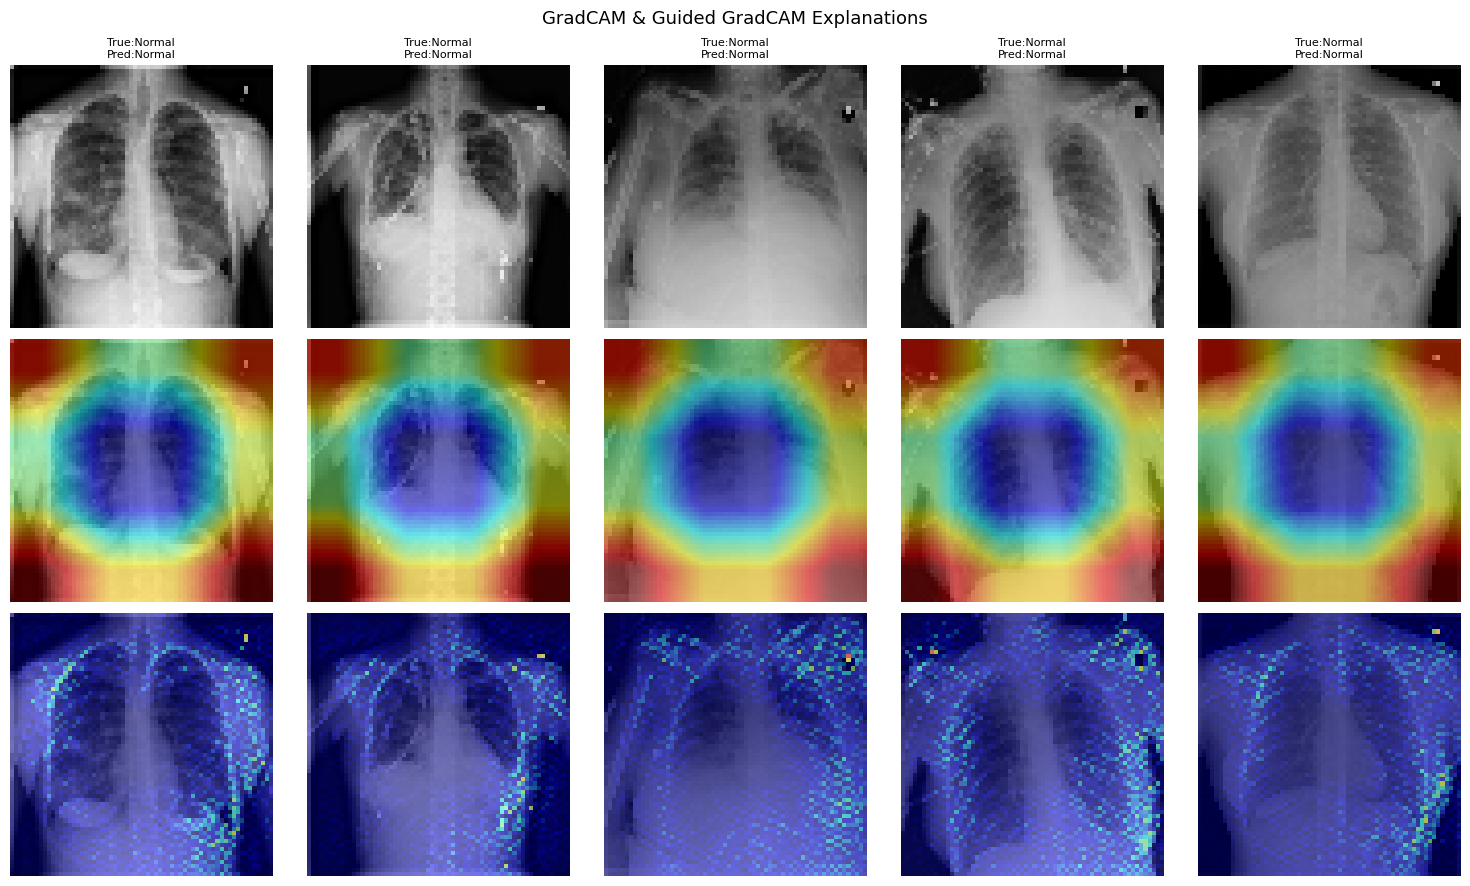

All XAI plots saved.


In [20]:
# ── Visualise GradCAM + Guided GradCAM ──────────────────────────────────────
fig, axes = plt.subplots(3, N_XAI_SAMPLES, figsize=(3*N_XAI_SAMPLES, 9))
row_titles = ['Original', 'GradCAM', 'Guided GradCAM']

for i in range(N_XAI_SAMPLES):
    img       = X_xai[i]                              # (64,64,3) float32
    img_batch = np.expand_dims(img, 0)                # (1,64,64,3)
    img_tf    = tf.cast(img_batch, tf.float32)

    cam, guided_cam, pred = get_guided_gradcam(cnn_model, img_tf, last_conv_name)

    grad_overlay   = overlay_heatmap(img, cam)
    guided_overlay = overlay_heatmap(img, guided_cam.mean(axis=-1))

    for row, vis in enumerate([img, grad_overlay, guided_overlay]):
        axes[row, i].imshow(np.clip(vis, 0, 1))
        axes[row, i].axis('off')
        if row == 0:
            axes[row, i].set_title(
                f'True:{CLASSES[y_xai[i]]}\nPred:{CLASSES[pred]}', fontsize=8)

for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=11, rotation=90, labelpad=4)

fig.suptitle('GradCAM & Guided GradCAM Explanations', fontsize=13)
plt.tight_layout(); plt.savefig('gradcam_explanations.png', dpi=150); plt.show()
print('All XAI plots saved.')

## Cell 17 — Summary Table

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# CNN alone
y_pred_cnn_prob = cnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_cnn      = np.argmax(y_pred_cnn_prob, axis=1)

def metrics(y_true, y_pred, label):
    return {
        'Model'    : label,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_true, y_pred,    average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred,        average='weighted'), 4),
    }

results = pd.DataFrame([
    metrics(y_test, y_pred_cnn,  'CNN only'),
    metrics(y_test, y_pred,      'CNN-XGBoost'),
])
print(results.to_string(index=False))

      Model  Accuracy  Precision  Recall  F1-Score
   CNN only    0.5000     0.2500  0.5000    0.3333
CNN-XGBoost    0.8011     0.8016  0.8011    0.8010
